# Memory, rematerialization, and optimization tradeoffs

Runnable locally on CPU or on a Cloud TPU VM.

- Explain why reverse-mode differentiation needs forward intermediates.
- Compare ordinary and rematerialized gradients with an independent reverse recurrence.
- Inspect saved residual descriptions and compiled memory estimates without equating them.
- Measure warm gradient calls and explain why a memory benefit is workload-dependent.

A model runs out of memory during differentiation. Someone suggests checkpointing every layer. Will that change the answer, and will it necessarily reduce this program’s memory? We will compare gradients, inspect saved residuals and measure compiled estimates and timings before making that decision.

## The idea

Reverse-mode differentiation needs information from forward execution. Rematerialization recomputes some of that information instead of retaining it. This exchanges storage for work inside a computation and is distinct from saving a training checkpoint to disk.

## Follow an intermediate from creation to last use

Imagine a backward rule needs an intermediate from the first operation in a chain. One strategy retains it; another reruns enough forward work to reconstruct it. Draw the value's lifetime and mark which computation is repeated.

Saved autodiff entries, estimated bytes and compiled peak memory are different quantities. Fusion, temporary buffers and reuse can change the compiled memory picture even when a source-level list of saved values changes.

Read each plot with its own units. Fewer entries alone are separate from lower peak device memory or faster execution. Use the storage model to form a hypothesis, then inspect compiler information and actual target behavior.

### Pause and reason

Why might fewer saved values leave compiled memory unchanged?

<details><summary>Compare your reasoning</summary>

The compiler may already eliminate or reuse them, while other temporaries dominate peak usage. Source-level counts do not fully determine compiled buffer lifetimes.

</details>

## Follow one layer backward

Our layer multiplies a vector by a fixed matrix and applies tanh. In the backward pass, the derivative of tanh uses the forward output. If that output is retained, the derivative can reuse it. If selected intermediates are discarded, the program must reconstruct the needed value from retained inputs and weights.

For layer output $h$, the local derivative factor is $1-h^2$. Multiplying the incoming cotangent by that factor, then applying the transposed weight matrix, propagates sensitivity to the preceding vector. The NumPy reference implements this recurrence explicitly instead of calling autodiff.

$$
\bar x=W^\top\bigl(\bar h\odot(1-h^2)\bigr)
$$

## Choose a boundary around pure work

We apply jax.checkpoint to the layer function. The outer objective uses four layers and a sum of squared final outputs. The reference and rematerialized versions share the same weights and input. If a function relies on untracked mutation, hidden randomness or effects, recomputation can have a different meaning; explicit state and keys remain essential.

Checkpointing the entire loss at an unhelpful boundary may simply recompute nearly all work without eliminating the intermediates you expected. Compare policies at meaningful blocks, and start with a small function whose derivative you can verify.

## Inspect what autodiff saves

print_saved_residuals names values retained for differentiation. The output describes a constant weight matrix and selected vector intermediates. Count the entries to compare policies, but read their shapes too: one large matrix may cost more than many scalar entries. The printed list is a diagnostic representation, not a device-memory allocation trace.

In this fixed example, the ordinary policy reports nine residual descriptions and layer rematerialization reports six. Those counts explain that the differentiation strategy changed; they do not guarantee a proportional reduction in peak bytes.

## Read compiled memory estimates separately

Compile the gradient for the same input contract and inspect memory_analysis. Argument, output, temporary and alias bytes answer different questions. Backend support and reporting conventions can vary, so record missing analysis as unavailable instead of substituting zero.

In the tested small CPU example, both policies report the same temporary-buffer estimate. That is a useful result: fewer saved autodiff values need not reduce this compiled program’s allocated temporary storage. Fusion, buffer reuse and compiler decisions stand between a mathematical strategy and a memory allocation.

## Measure the tradeoff you actually care about

Warm both compiled gradients and collect synchronized calls. Keep all samples, not just the fastest. Rematerialization can add arithmetic; on a tiny workload, dispatch and noise can dominate. No strict timing ordering is required.

A training-memory claim requires the complete training step, representative model and batch shapes, and actual peak memory on the target device. Include optimizer state and input buffers. Test whether the policy enables the intended larger batch without changing the objective, then verify quality and runtime again.

## Define two differentiation policies

Create a Python file in the course environment. Add this block after the preceding block, then run the assembled file.

In [1]:
# Step 1 — Define two differentiation policies: Both functions compute the same pure objective; only the...
# Import contextlib for this computation.
import contextlib
import io
import time
import numpy as np
import jax
import jax.numpy as jnp
from jax.ad_checkpoint import print_saved_residuals
# Draw pseudorandom samples for `rng` using the explicit RNG state.
rng=np.random.default_rng(18)
# Create device-backed JAX array `w`.
w=jnp.asarray((rng.normal(size=(16,16))*.1).astype(np.float32))
# Compute `x` from `jnp.asarray(np.linspace(-.5,.5,16,dtype=np.float32))`
x=jnp.asarray(np.linspace(-.5,.5,16,dtype=np.float32))
# Function `layer(v)` implementing this stage's computation:
# Return `jnp.tanh(w @ v)` to the caller.
def layer(v):return jnp.tanh(w@v)
# Function `objective(v, rematerialize)` implementing this stage's computation:
def objective(v,rematerialize=False):
    # Run `jax.checkpoint` to compute `operation`.
    operation=jax.checkpoint(layer) if rematerialize else layer
    # Repeat the update loop over `range(4)` steps:
    # Run `operation` to compute `v`.
    for _ in range(4):v=operation(v)
    # Return `jnp.sum(v * v)` to the caller.
    return jnp.sum(v*v)
# Compute `plain` from `lambda v:objective(v,False)`
plain=lambda v:objective(v,False)
# Compute `remat` from `lambda v:objective(v,True)`
remat=lambda v:objective(v,True)
# Function `residual_report(fn)` implementing this stage's computation:
def residual_report(fn):
    # Run `io.StringIO` to compute `stream`.
    stream=io.StringIO()
    # Enter `contextlib.redirect_stdout(stream)` context block:
    with contextlib.redirect_stdout(stream):print_saved_residuals(fn,x)
    # Compute `lines` from `[line for line in stream.getvalue().splitlines() if ...`
    lines=[line for line in stream.getvalue().splitlines() if line.strip()]
    # Return `lines` to the caller.
    return lines
# Compute `reports` from `[residual_report(plain),residual_report(remat)]`
reports=[residual_report(plain),residual_report(remat)]

Both functions compute the same pure objective; only the recomputation boundary differs. The diagnostic records descriptions rather than claiming physical byte savings.

## Verify with an independent reverse pass

Create a Python file in the course environment. Add this block after the preceding block, then run the assembled file.

In [2]:
# Independent reverse recurrence through the same explicitly specified network.
host_w=np.asarray(w)
values=[np.asarray(x)]
# Repeat the update loop over `range(4)` steps:
# Perform matrix contraction / projection to compute ``.
for _ in range(4):values.append(np.tanh(host_w@values[-1]))
# Compute `cotangent` from `2*values[-1]`
cotangent=2*values[-1]
# Iterate over `i` to step through the computation:
for i in range(4,0,-1):cotangent=host_w.T@(cotangent*(1-values[i]**2))
# Iterate over `fn` to step through the computation:
for fn in (plain,remat):
    # Differentiate the objective to obtain gradients ``.
    np.testing.assert_allclose(jax.grad(fn)(x),cotangent,rtol=3e-5,atol=1e-7)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(plain)(x),jax.grad(remat)(x),rtol=1e-6,atol=1e-7)
# Differentiate the objective to obtain `executables` via automatic differentiation.
executables=[jax.jit(jax.grad(fn)).lower(x).compile() for fn in (plain,remat)]
# Evaluate `memory` from the current inputs and state.
# Compute `memory` from `[]`
memory=[]
times=[]
# Iterate over `executable` to step through the computation:
for executable in executables:
    # Run `executable.memory_analysis` to compute `analysis`.
    analysis=executable.memory_analysis()
    # Append the current step result to `memory`.
    memory.append(None if analysis is None else {name:getattr(analysis,name) for name in ('argument_size_in_bytes','output_size_in_bytes','temp_size_in_bytes','alias_size_in_bytes')})
    # Synchronize host execution until asynchronous device computation completes.
    # Synchronize host execution until asynchronous device computation completes.
    executable(x).block_until_ready()
    samples=[]
    # Repeat the update loop over `range(5)` steps:
    for _ in range(5):
        # Synchronize host execution until asynchronous device computation completes.
        # Synchronize host execution until asynchronous device computation completes.
        # Synchronize host execution until asynchronous device computation completes.
        start=time.perf_counter()
        executable(x).block_until_ready()
        samples.append(time.perf_counter()-start)
    # Append the current step result to `times`.
    times.append(samples)
# Print the observed values to compare against the expected result.
print('Saved residual descriptions:')
# Iterate over `(name, lines)` to step through the computation:
for name,lines in zip(['plain','remat'],reports):print(name,'\n'+'\n'.join(lines))
# Print the observed values to compare against the expected result.
print('Compiler memory estimates:',memory)
# Print diagnostic summary of the computed outputs.
print('Synchronized gradient samples:',times)
# Print diagnostic summary of the computed outputs.
print('Independent reverse recurrence agrees with both gradients.')

The NumPy recurrence propagates cotangents through saved host activations, providing an oracle independent of JAX differentiation.

## Step 3: Verify invariants on the completed state

Run the final shape and numerical assertions to confirm the state built in Steps 1 and 2.

In [3]:
    times.append(samples)
for name,lines in zip(['plain','remat'],reports):print(name,'\n'+'\n'.join(lines))

Checking these invariants confirms the computation is ready for the full worked experiment.

## Run the example

In [4]:
# Step 1 — Define two differentiation policies: Both functions compute the same pure objective; only the...
# Import contextlib for this computation.
import contextlib
import io
import time
import numpy as np
import jax
import jax.numpy as jnp
from jax.ad_checkpoint import print_saved_residuals
# Draw pseudorandom samples for `rng` using the explicit RNG state.
rng=np.random.default_rng(18)
# Create device-backed JAX array `w`.
w=jnp.asarray((rng.normal(size=(16,16))*.1).astype(np.float32))
# Compute `x` from `jnp.asarray(np.linspace(-.5,.5,16,dtype=np.float32))`
x=jnp.asarray(np.linspace(-.5,.5,16,dtype=np.float32))
# Function `layer(v)` implementing this stage's computation:
# Return `jnp.tanh(w @ v)` to the caller.
def layer(v):return jnp.tanh(w@v)
# Function `objective(v, rematerialize)` implementing this stage's computation:
def objective(v,rematerialize=False):
    # Run `jax.checkpoint` to compute `operation`.
    operation=jax.checkpoint(layer) if rematerialize else layer
    # Repeat the update loop over `range(4)` steps:
    # Run `operation` to compute `v`.
    for _ in range(4):v=operation(v)
    # Return `jnp.sum(v * v)` to the caller.
    return jnp.sum(v*v)
# Compute `plain` from `lambda v:objective(v,False)`
plain=lambda v:objective(v,False)
# Compute `remat` from `lambda v:objective(v,True)`
remat=lambda v:objective(v,True)
# Function `residual_report(fn)` implementing this stage's computation:
def residual_report(fn):
    # Run `io.StringIO` to compute `stream`.
    stream=io.StringIO()
    # Enter `contextlib.redirect_stdout(stream)` context block:
    with contextlib.redirect_stdout(stream):print_saved_residuals(fn,x)
    # Compute `lines` from `[line for line in stream.getvalue().splitlines() if ...`
    lines=[line for line in stream.getvalue().splitlines() if line.strip()]
    # Return `lines` to the caller.
    return lines
# Compute `reports` from `[residual_report(plain),residual_report(remat)]`
reports=[residual_report(plain),residual_report(remat)]

# Independent reverse recurrence through the same explicitly specified network.
host_w=np.asarray(w)
values=[np.asarray(x)]
# Repeat the update loop over `range(4)` steps:
# Perform matrix contraction / projection to compute ``.
for _ in range(4):values.append(np.tanh(host_w@values[-1]))
# Compute `cotangent` from `2*values[-1]`
cotangent=2*values[-1]
# Iterate over `i` to step through the computation:
for i in range(4,0,-1):cotangent=host_w.T@(cotangent*(1-values[i]**2))
# Iterate over `fn` to step through the computation:
for fn in (plain,remat):
    # Differentiate the objective to obtain gradients ``.
    np.testing.assert_allclose(jax.grad(fn)(x),cotangent,rtol=3e-5,atol=1e-7)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(plain)(x),jax.grad(remat)(x),rtol=1e-6,atol=1e-7)
# Differentiate the objective to obtain `executables` via automatic differentiation.
executables=[jax.jit(jax.grad(fn)).lower(x).compile() for fn in (plain,remat)]
# Evaluate `memory` from the current inputs and state.
# Compute `memory` from `[]`
memory=[]
times=[]
# Iterate over `executable` to step through the computation:
for executable in executables:
    # Run `executable.memory_analysis` to compute `analysis`.
    analysis=executable.memory_analysis()
    # Append the current step result to `memory`.
    memory.append(None if analysis is None else {name:getattr(analysis,name) for name in ('argument_size_in_bytes','output_size_in_bytes','temp_size_in_bytes','alias_size_in_bytes')})
    # Synchronize host execution until asynchronous device computation completes.
    # Synchronize host execution until asynchronous device computation completes.
    executable(x).block_until_ready()
    samples=[]
    # Repeat the update loop over `range(5)` steps:
    for _ in range(5):
        # Synchronize host execution until asynchronous device computation completes.
        # Synchronize host execution until asynchronous device computation completes.
        # Synchronize host execution until asynchronous device computation completes.
        start=time.perf_counter()
        executable(x).block_until_ready()
        samples.append(time.perf_counter()-start)
    # Append the current step result to `times`.
    times.append(samples)
# Print the observed values to compare against the expected result.
print('Saved residual descriptions:')
# Iterate over `(name, lines)` to step through the computation:
for name,lines in zip(['plain','remat'],reports):print(name,'\n'+'\n'.join(lines))
# Print the observed values to compare against the expected result.
print('Compiler memory estimates:',memory)
# Print diagnostic summary of the computed outputs.
print('Synchronized gradient samples:',times)
# Print diagnostic summary of the computed outputs.
print('Independent reverse recurrence agrees with both gradients.')

Saved residual descriptions:
plain 
f32[16,16] from a constant
f32[16] output of tanh from /Users/tahabsn/Documents/ChatGPT/jaxpathways/phases/08-performance/05-memory-rematerialization-and-optimization-tradeoffs/notebooks/exercise.ipynb:cell-1:11:20 (layer)
f32[16] output of sub from /Users/tahabsn/Documents/ChatGPT/jaxpathways/phases/08-performance/05-memory-rematerialization-and-optimization-tradeoffs/notebooks/exercise.ipynb:cell-1:11:20 (layer)
f32[16] output of tanh from /Users/tahabsn/Documents/ChatGPT/jaxpathways/phases/08-performance/05-memory-rematerialization-and-optimization-tradeoffs/notebooks/exercise.ipynb:cell-1:11:20 (layer)
f32[16] output of sub from /Users/tahabsn/Documents/ChatGPT/jaxpathways/phases/08-performance/05-memory-rematerialization-and-optimization-tradeoffs/notebooks/exercise.ipynb:cell-1:11:20 (layer)
f32[16] output of tanh from /Users/tahabsn/Documents/ChatGPT/jaxpathways/phases/08-performance/05-memory-rematerialization-and-optimization-tradeoffs/noteb

Expected: Both gradients agree with the independent reverse recurrence. The saved-residual descriptions differ; the small tested CPU program reports equal temporary-memory estimates. Timings vary and no speedup is asserted.

## Changed autodiff storage does not guarantee changed compiled buffers

Predict: Must the two panels tell the same story about memory?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Changed autodiff storage does not guarantee changed compiled buffers
# Compute `panels` from `[{'kind':'bar','title':'Autodiff residual descriptio...`
panels=[{'kind':'bar','title':'Autodiff residual descriptions','labels':['ordinary','layer remat'],'ylabel':'saved entries (not bytes)','series':[{'label':'residual descriptions','y':[len(r) for r in reports]}]}]
# Branch on condition `all((m is not None for m in memory))`:
if all(m is not None for m in memory):
    panels.append({'kind':'bar','title':'Compiler memory estimate','labels':['ordinary','layer remat'],'ylabel':'estimated temporary bytes','series':[{'label':'compiler temporaries','y':[m['temp_size_in_bytes'] for m in memory]}]})
else:
    panels.append({'kind':'bar','title':'Compiler memory analysis unavailable','labels':['ordinary','layer remat'],'ylabel':'analysis available (1=yes)','series':[{'label':'availability, not byte count','y':[int(m is not None) for m in memory]}]})
# Compute `visual_data` from `{'kind':'panels','panels':panels}`
visual_data={'kind':'panels','panels':panels}

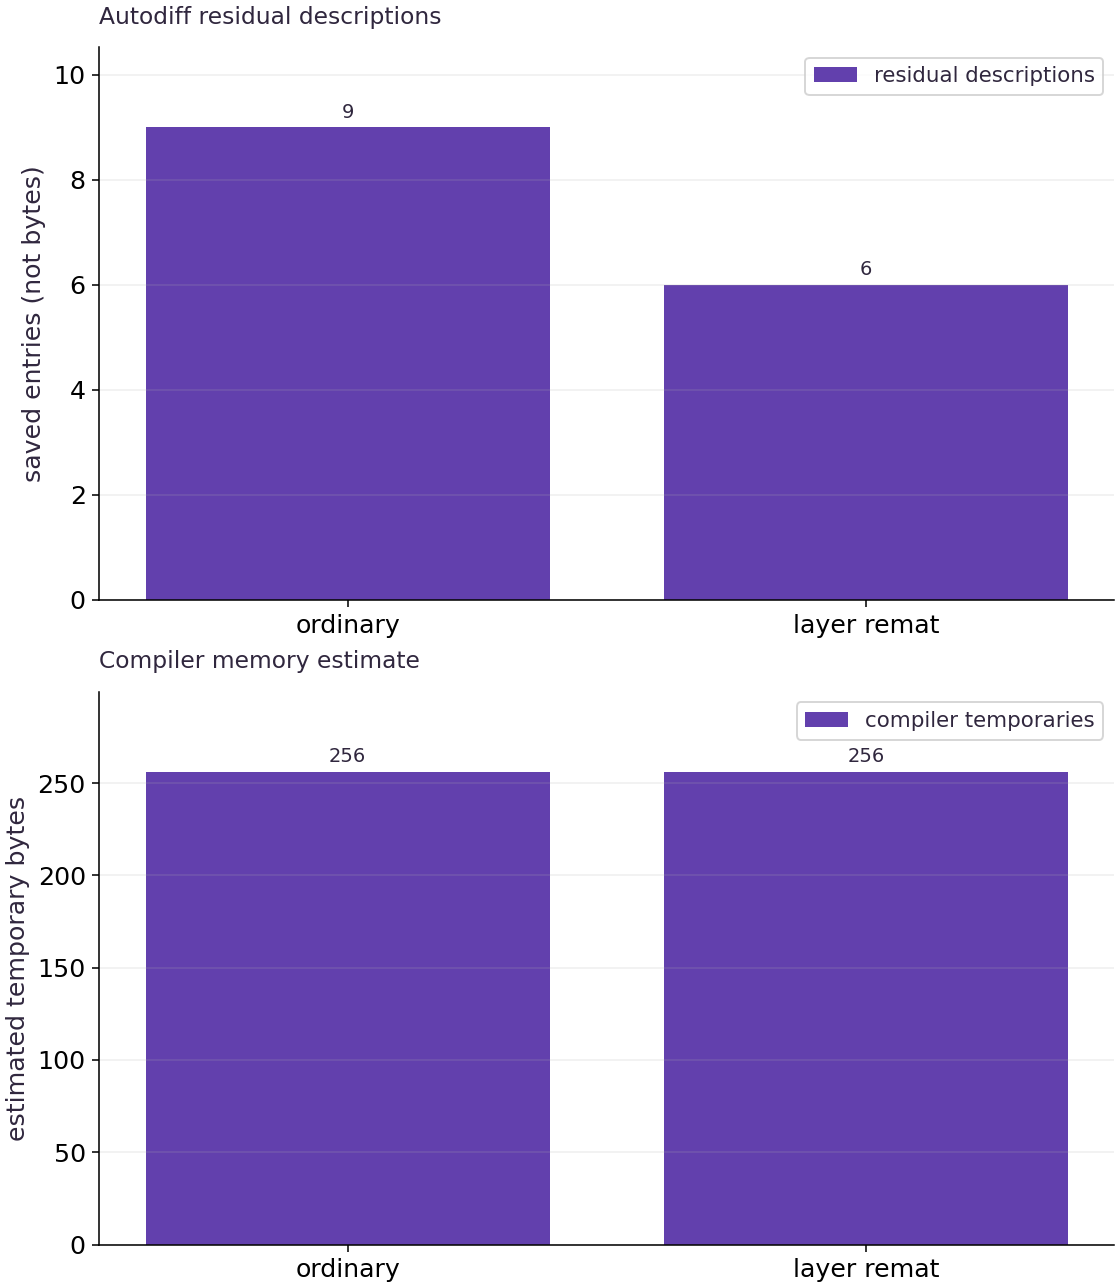

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The upper panel counts saved-residual descriptions for ordinary differentiation and layer rematerialization. The vertical unit is entries, not bytes. In this fixed network the counts are nine and six, including a shared constant matrix; the decrease shows a changed differentiation strategy.

The lower panel reports compiler-estimated temporary bytes when that analysis is supported. In the recorded CPU example both bars have height $256$. Equal bars mean the compiler reports no reduction in this category for these shapes, even though the residual-entry count decreased.

### Connect it to the computation

The independent reverse recurrence checks the numerical derivative for both policies. The figure then compares two distinct storage views: values named by autodiff and temporary buffers estimated after compilation. Compiler reuse and fusion can make their relationship non-proportional.

These are not measurements of peak accelerator allocation or total training memory. The runtime samples are recorded separately, and a meaningful policy decision needs representative model size, optimizer state and actual target-device measurements. If a backend lacks memory analysis, the plot explicitly substitutes a labeled availability panel rather than treating missing bytes as zero.

## Move the boundary to the entire objective

Predict: Will checkpointing the whole objective preserve the gradient? Does that alone demonstrate useful memory savings?

In [7]:
# Experiment — Move the boundary to the entire objective: Correctness is necessary but does not choose the best policy.
whole=jax.checkpoint(plain)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(whole)(x),cotangent,rtol=3e-5,atol=1e-7)
# Print the observed values to compare against the expected result.
print('Whole-objective residuals:',residual_report(whole))
# Differentiate the objective to obtain `whole_executable` via automatic differentiation.
whole_executable=jax.jit(jax.grad(whole)).lower(x).compile()
# Print the observed values to compare against the expected result.
print('Whole-objective memory estimate:',whole_executable.memory_analysis())

Expected: The derivative remains correct; residual and compiled-memory reports describe this additional boundary.

Correctness is necessary but does not choose the best policy. The boundary determines what is retained and recomputed; inspect actual memory and timing for the intended workload.

## Your exercise

Use the direction $v=(1,\ldots,1)$ and central differences to independently check a directional derivative of the original objective at the existing input. Compare it with the gradient dot direction and report the perturbation.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Construct `direction` via `jnp.ones_like(x)`
2. Compute `finite` from `(float(plain(x+eps*direction))-float(plain(x-eps*dir...`
3. Differentiate the objective to obtain `automatic` via automatic differentiation.
4. Check numerical equivalence within tolerance: `np.testing.assert_allclose(finite,automatic,rtol=3e-3,atol=1e-6)`
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Use the direction v=(1,\ldots,1) and central differences to...
# Construct `direction` via `jnp.ones_like(x)`
direction = jnp.ones_like(...)  # TODO: compute direction
eps = ...  # TODO: compute eps
# Compute `finite` from `(float(plain(x+eps*direction))-float(plain(x-eps*dir...`
finite = ...  # TODO: compute finite
# Differentiate the objective to obtain `automatic` via automatic differentiation.
automatic = float(...)  # TODO: compute automatic
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(finite,automatic,rtol=3e-3,atol=1e-6)`
np.testing.assert_allclose(finite,automatic,rtol = ...  # TODO: compute np.testing.assert_allclose(finite,automatic,rtol
# Print the observed values to compare against the expected result.
print('Directional derivative finite/automatic:',finite,automatic,'epsilon',eps)
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Use the direction v=(1,\ldots,1) and central differences to...
# Construct `direction` via `jnp.ones_like(x)`
# direction = jnp.ones_like(...)  # TODO: compute direction
# eps = ...  # TODO: compute eps
# Compute `finite` from `(float(plain(x+eps*direction))-float(plain(x-eps*dir...`
# finite = ...  # TODO: compute finite
# Differentiate the objective to obtain `automatic` via automatic differentiation.
# automatic = float(...)  # TODO: compute automatic
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(finite,automatic,rtol=3e-3,atol=1e-6)`
# np.testing.assert_allclose(finite,automatic,rtol = ...  # TODO: compute np.testing.assert_allclose(finite,automatic,rtol
# Print the observed values to compare against the expected result.
# print('Directional derivative finite/automatic:',finite,automatic,'epsilon',eps)

## Reference solution

Try your own implementation first.

In [9]:
# Exercise solution: Use the direction v=(1,\ldots,1) and central differences to...
# Construct `direction` via `jnp.ones_like(x)`
direction=jnp.ones_like(x)
eps=.001
# Compute `finite` from `(float(plain(x+eps*direction))-float(plain(x-eps*dir...`
finite=(float(plain(x+eps*direction))-float(plain(x-eps*direction)))/(2*eps)
# Differentiate the objective to obtain `automatic` via automatic differentiation.
automatic=float(jnp.vdot(jax.grad(plain)(x),direction))
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(finite,automatic,rtol=3e-3,atol=1e-6)`
np.testing.assert_allclose(finite,automatic,rtol=3e-3,atol=1e-6)
# Print the observed values to compare against the expected result.
print('Directional derivative finite/automatic:',finite,automatic,'epsilon',eps)

## Check higher-order differentiation · Transfer

Compare Hessian-vector products of the ordinary and rematerialized objectives along a nonuniform direction. Explain why equal first derivatives alone would be a weaker test.

Hint: Apply jvp to each gradient function with the same primal point and tangent.

### How to write: Check higher-order differentiation — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.linspace(start, stop, num)` — Creates `num` evenly spaced float points across the closed interval `[start, stop]`.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jnp.isfinite(x)` — Returns a boolean mask verifying that no element is `NaN` or `Inf`.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Construct `direction` via `jnp.linspace(-1.,1.,len(x))`
2. Differentiate the objective to obtain `(_, hvp_plain)` via automatic differentiation.
3. Differentiate the objective to obtain `(_, hvp_remat)` via automatic differentiation.
4. Check numerical equivalence within tolerance: `np.testing.assert_allclose(hvp_plain,hvp_remat,rtol=3e-5,atol=1e-7)`
5. Confirm that all computed values remain finite (no NaN or Inf).

**Starter code scaffold (fill in the TODOs):**

```python
# Check higher-order differentiation (Transfer): Recomputation should preserve the differentiable function in...
# Construct `direction` via `jnp.linspace(-1.,1.,len(x))`
direction = jnp.linspace(...)  # TODO: compute direction
# Differentiate the objective to obtain `(_, hvp_plain)` via automatic differentiation.
_,hvp_plain = jax.jvp(...)  # TODO: compute _,hvp_plain
# Differentiate the objective to obtain `(_, hvp_remat)` via automatic differentiation.
_,hvp_remat = jax.jvp(...)  # TODO: compute _,hvp_remat
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(hvp_plain,hvp_remat,rtol=3e-5,atol=1e-7)`
np.testing.assert_allclose(hvp_plain,hvp_remat,rtol = ...  # TODO: compute np.testing.assert_allclose(hvp_plain,hvp_remat,rtol
# Confirm that all computed values remain finite (no NaN or Inf).
assert np.isfinite(np.asarray(hvp_plain)).all()  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Higher-order directional derivatives agree.')
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check higher-order differentiation (Transfer): Recomputation should preserve the differentiable function in...
# Construct `direction` via `jnp.linspace(-1.,1.,len(x))`
# direction = jnp.linspace(...)  # TODO: compute direction
# Differentiate the objective to obtain `(_, hvp_plain)` via automatic differentiation.
# _,hvp_plain = jax.jvp(...)  # TODO: compute _,hvp_plain
# Differentiate the objective to obtain `(_, hvp_remat)` via automatic differentiation.
# _,hvp_remat = jax.jvp(...)  # TODO: compute _,hvp_remat
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(hvp_plain,hvp_remat,rtol=3e-5,atol=1e-7)`
# np.testing.assert_allclose(hvp_plain,hvp_remat,rtol = ...  # TODO: compute np.testing.assert_allclose(hvp_plain,hvp_remat,rtol
# Confirm that all computed values remain finite (no NaN or Inf).
# assert np.isfinite(np.asarray(hvp_plain)).all()  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Higher-order directional derivatives agree.')

## Reference reasoning

Recomputation should preserve the differentiable function in this pure example, including its higher-order directional behavior. This still is separate from a device-memory improvement.

In [11]:
# Check higher-order differentiation (Transfer): Recomputation should preserve the differentiable function in...
# Construct `direction` via `jnp.linspace(-1.,1.,len(x))`
direction=jnp.linspace(-1.,1.,len(x))
# Differentiate the objective to obtain `(_, hvp_plain)` via automatic differentiation.
_,hvp_plain=jax.jvp(jax.grad(plain),(x,),(direction,))
# Differentiate the objective to obtain `(_, hvp_remat)` via automatic differentiation.
_,hvp_remat=jax.jvp(jax.grad(remat),(x,),(direction,))
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(hvp_plain,hvp_remat,rtol=3e-5,atol=1e-7)`
np.testing.assert_allclose(hvp_plain,hvp_remat,rtol=3e-5,atol=1e-7)
# Confirm that all computed values remain finite (no NaN or Inf).
assert np.isfinite(np.asarray(hvp_plain)).all()
# Print the observed values to compare against the expected result.
print('Higher-order directional derivatives agree.')

## Checkpoint

Rematerialization reduces the number of saved residual descriptions but the compiled temporary-byte estimates are equal. What is the supported conclusion?

1. The compiler’s report must be wrong.
2. The differentiation strategy changed, but this evidence does not show reduced compiled temporary storage.
3. The model must train faster because fewer values were listed.

## Diagnose

If gradients differ, first compare inputs, weights, random keys and any hidden effects. If memory does not improve, inspect the checkpoint boundary, residual shapes, compiler buffer estimates and full-step peak measurements before adding more checkpoint wrappers.

## Evidence

Keep the plain/rematerialized gradient and HVP comparisons, saved-residual counts, compiler-memory observations and synchronized timings. Explain why fewer residuals do not guarantee lower measured memory.

## Carry forward

- Recomputation trades retained intermediate values for extra work.
- Verify the derivative independently before evaluating a policy.
- Saved values, estimated buffers and measured peak memory must remain distinct.

## Primary references

- [JAX gradient checkpointing](https://docs.jax.dev/en/latest/gradient-checkpointing.html)
- [JAX benchmarking](https://docs.jax.dev/en/latest/benchmarking.html)